In [11]:
import os
import sys

import seaborn as sns

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 18})

# Using PCA dimensionality reduction to qualitatively estimate the classifier's performance on the unlabeled test set

Now that we've trained the fault detection classifier, we want to check its generability on the official test set. During training, we used the holdout method to select the test set as a subset of the data set, but remember: *this data set was the training set of the challenge to begin with*. Therefore, since its samples come from 4 different engines, but their identity is unknown, there is inevitably a redundancy between the selected test set and the train set.

That said, the challenge website also offers a validation and a test set, unfortunately unlabelled to date. They contain $21.436$ samples each, for a total of $42.872$ samples, all recorded from 3 different engines than the 4 from which the train set was taken.

In [12]:
train_x, train_y = read_dataset('original', normalization='standardize')
_original_x, _ = read_dataset('original')
train_mean, train_std = _original_x.mean(), _original_x.std()

test_x = read_dataset(stage='original', testset=True)
test_x_std_on_train = (test_x - train_mean) / train_std

train_pred = pd.read_csv('../3-fault_detection/predictions_train.csv')['faulty']
test_pred = pd.read_csv('../3-fault_detection/predictions_test.csv')['faulty']

## Visualizing the test set distribution alongside the train set

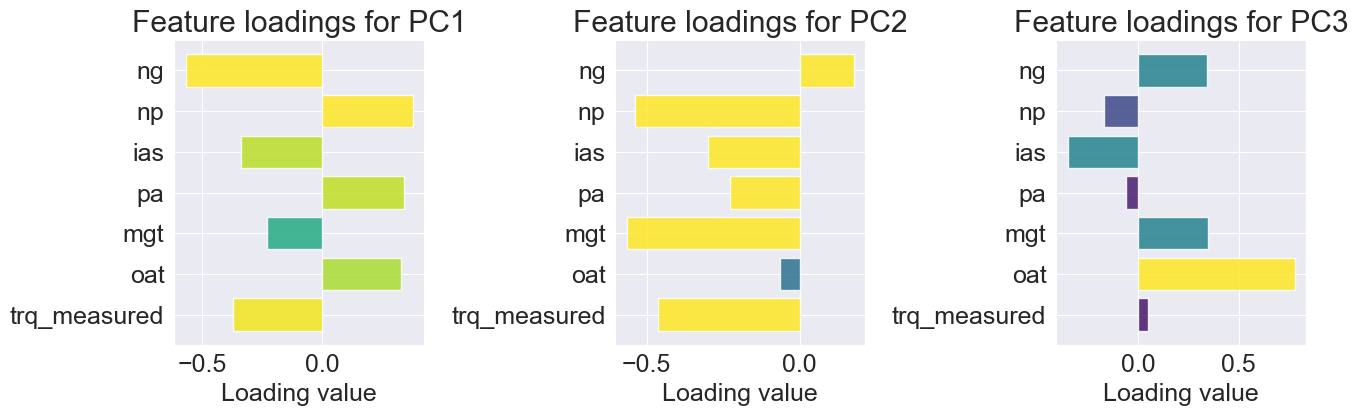

<Axes3D: >

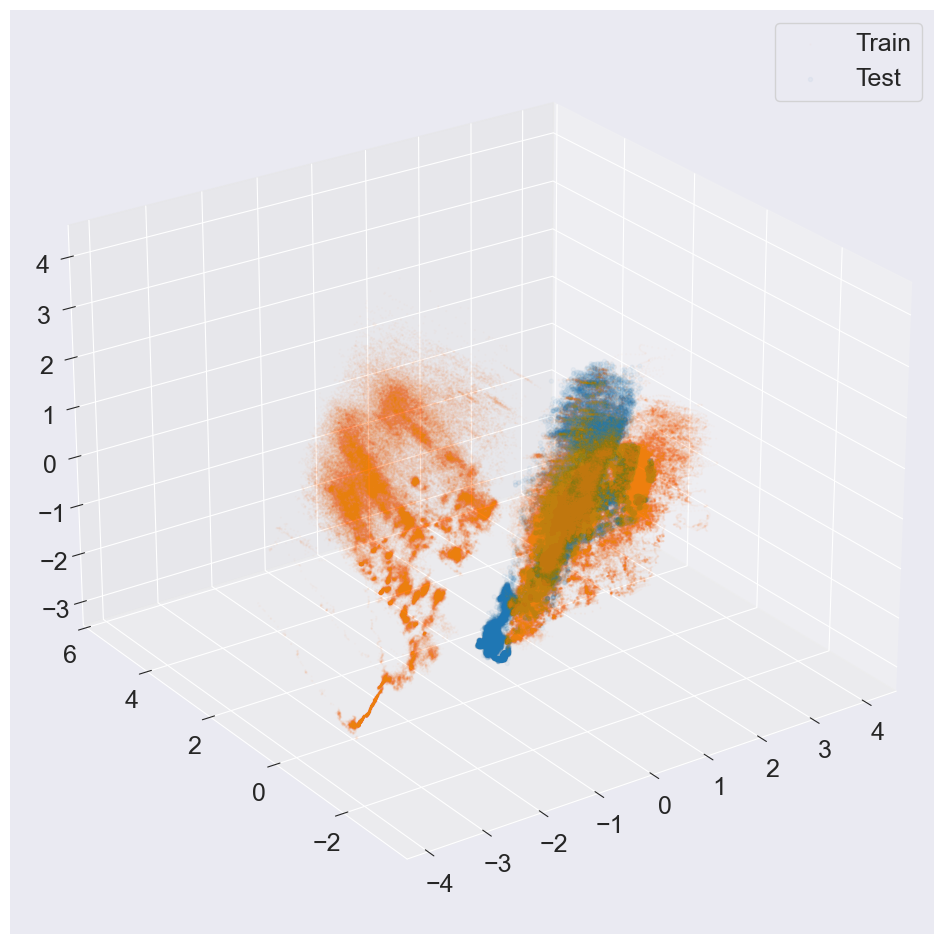

In [13]:
# 16s
train_pca = PCA(train_x)
test_pca = PCA(test_x_std_on_train, loadings=train_pca.loadings)
train_pca.plot_loadings(scale=0.75, is_3d=True)
ax = train_pca.plot_pca(is_3d=True, hue=np.zeros(len(train_x)), labels={0: 'Train'}, c={0: 'tab:orange'}, scale=1,
                        alpha=0.015)
test_pca.plot_pca(is_3d=True, hue=np.zeros(len(test_x_std_on_train)), labels={0: 'Test'}, c={0: 'tab:blue'}, ax=ax)

## Visualizing the test set predictions distribution alongside those of the train set
If you compare the following figure with that at the bottom of notebbok [`4.1-Qualitative_Evaluation_PCA.ipynb`](4.1-Qualitative_Evaluation_PCA.ipynb), you can see that the KNN mostly aligns with the PyKAN in the center of the right cluster, but significantly differs in the top and bottom parts.

<Axes3D: >

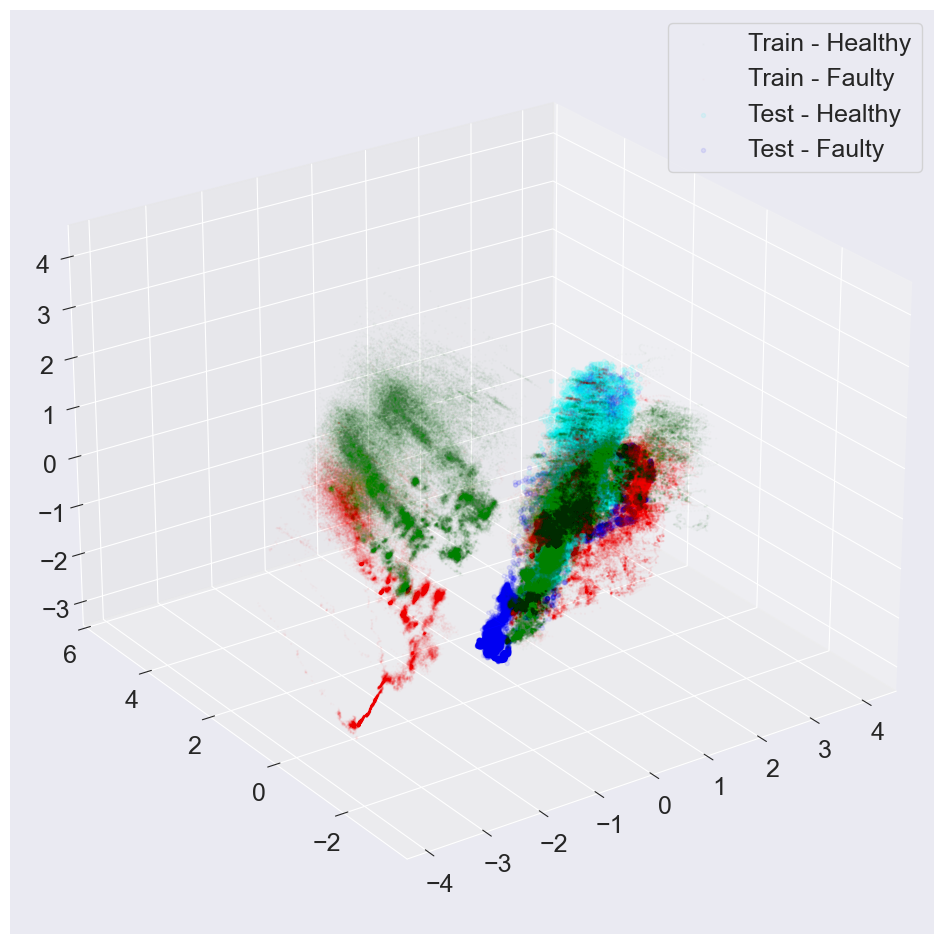

In [14]:
# 16s
ax = train_pca.plot_pca(is_3d=True, hue=train_pred > 0.5, labels={0: 'Train - Healthy', 1: 'Train - Faulty'}, scale=1,
                        alpha=0.01)
test_pca.plot_pca(is_3d=True, hue=test_pred > 0.5, labels={0: 'Test - Healthy', 1: 'Test - Faulty'},
                  c={0: 'cyan', 1: 'blue'}, ax=ax,alpha=0.075)